# 🌦️ Cambodia Weather Forecast Analysis
### Fundamentals of Data Science Project
Cambodia Academy of Digital Technology (Group 4)

This notebook is our working analysis for Cambodia weather data from the government API.

Instead of only showing charts, we also write down practical observations from each run so the team can compare changes over time (temperature shifts, humidity patterns, and station differences).

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Fetch Weather Data
Collect real-time weather data from Cambodia government API for analysis of temperature, humidity, and climate trends.

In [ ]:
import requests
from requests.exceptions import SSLError
import warnings

url = "https://data.mef.gov.kh/api/v1/realtime-api/weather"

# Try secure request first; fallback only if SSL handshake fails.
try:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
except SSLError:
    warnings.warn("SSL verification failed, retrying with verify=False.", RuntimeWarning)
    response = requests.get(url, verify=False, timeout=30)
    response.raise_for_status()

data = response.json()
records = data.get("data", [])

df = pd.json_normalize(records)

# Parse datetime columns when available.
for col in ["created_at", "last_updated"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Add ingestion timestamp for reproducibility.
df["fetched_at_utc"] = pd.Timestamp.utcnow()

print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print("Columns:", df.columns.tolist())
display(df.head())

C:\Users\ROG\AppData\Local\Temp\ipykernel_1148\1765029285.py:12: RuntimeWarning: SSL verification failed, retrying with verify=False.
  warnings.warn("SSL verification failed, retrying with verify=False.", RuntimeWarning)
c:\Python\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data.mef.gov.kh'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Rows: 25 | Columns: 35
Columns: ['temp_c', 'wind_dir', 'feelslike_f', 'vis_miles', 'created_at', 'temp_f', 'pressure_mb', 'windchill_c', 'uv', 'is_day', 'pressure_in', 'windchill_f', 'gust_mph', 'precip_mm', 'heatindex_c', 'gust_kph', 'wind_mph', 'precip_in', 'heatindex_f', 'id', 'last_updated_epoch', 'humidity', 'dewpoint_c', 'wind_kph', 'cloud', 'dewpoint_f', 'last_updated', 'wind_degree', 'feelslike_c', 'vis_km', 'name', 'condition.text', 'condition.icon', 'condition.code', 'fetched_at_utc']


,temp_c,wind_dir,feelslike_f,vis_miles,created_at,temp_f,pressure_mb,windchill_c,uv,is_day,...,dewpoint_f,last_updated,wind_degree,feelslike_c,vis_km,name,condition.text,condition.icon,condition.code,fetched_at_utc
0,31.1,WSW,90.1,5.0,2026-03-25 12:45:08.329290+07:00,88.0,1011.0,34.1,None,True,...,68.4,2026-03-25 12:45:00,253,32.3,9.0,Strung Treng,Partly cloudy,//cdn.weatherapi.com/weather/64x64/day/116.png,1003,2026-03-25 06:18:43.148467+00:00
1,31.1,ESE,86.8,5.0,2026-03-25 12:45:08.329290+07:00,88.0,1011.0,38.0,None,True,...,65.2,2026-03-25 12:45:00,119,30.4,9.0,Pailin,Partly cloudy,//cdn.weatherapi.com/weather/64x64/day/116.png,1003,2026-03-25 06:18:43.148467+00:00
2,37.0,SSE,102.4,6.0,2026-03-25 13:00:10.047729+07:00,98.6,1009.0,37.0,None,True,...,63.5,2026-03-25 12:45:00,147,39.1,10.0,Battambang,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:18:43.148467+00:00
3,35.9,SSW,99.6,6.0,2026-03-25 13:00:10.047729+07:00,96.7,1008.0,35.9,None,True,...,62.7,2026-03-25 13:00:00,211,37.6,10.0,Koh Kong,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:18:43.148467+00:00
4,37.0,ESE,99.2,6.0,2026-03-25 13:00:10.047729+07:00,98.6,1008.0,37.0,None,True,...,57.9,2026-03-25 13:00:00,105,37.3,10.0,Kampot,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:18:43.148467+00:00


In [ ]:
# Check unique station names
if 'name' in df.columns:
    print("Available station names:")
    print(df['name'].unique())
else:
    print("No 'name' column found. Check API structure.")

Available station names:
['Preah Vihear' 'Oddar Meanchey' 'Siem Reap' 'Svay Rieng'
 'Banteay Meanchey' 'Prey Veng' 'Strung Treng' 'Pailin' 'Ratanakiri'
 'Phnom Penh' 'Sihanoukville' 'Battambang' 'Takeo' 'Koh Kong' 'Kratie'
 'Kampot' 'Kep' 'Kampong Thom' 'Mondulkiri' 'Kandal' 'Kampong Chhnang'
 'Tboung Khmum' 'Kampong Speu' 'Kampong Cham' 'Pursat']


### Data Cleaning Notes
Before exploring patterns, we clean the raw API output so the charts are trustworthy.

- Convert date columns to datetime format
- Convert weather measurements to numeric values
- Remove exact duplicates
- Check which columns still have missing values

In [ ]:
# Build clean working copy
df_clean = df.copy()

# Convert potential numeric columns safely (if present).
candidate_numeric_cols = [
    "temp_c", "temp_f", "feelslike_c", "feelslike_f", "humidity",
    "wind_kph", "wind_mph", "gust_kph", "gust_mph", "pressure_mb",
    "pressure_in", "precip_mm", "precip_in", "uv", "cloud", "vis_km",
    "vis_miles", "dewpoint_c", "dewpoint_f", "wind_degree", "is_day"
]

for col in candidate_numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Standardize station names for grouping.
if "name" in df_clean.columns:
    df_clean["name"] = df_clean["name"].astype(str).str.strip()

# Remove exact duplicate rows, then report diagnostics.
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f"Rows before dedup: {before}, after dedup: {after}, removed: {before - after}")

missing_summary = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_clean) * 100).round(2)

print("Top columns with missing values:")
display(missing_summary.head(10))

print("Cleaned data preview:")
display(df_clean.head())

Rows before dedup: 25, after dedup: 25, removed: 0
Top columns with missing values:


,missing_count,missing_pct
uv,25,100.0
wind_dir,0,0.0
temp_c,0,0.0
feelslike_f,0,0.0
vis_miles,0,0.0
temp_f,0,0.0
created_at,0,0.0
pressure_mb,0,0.0
windchill_c,0,0.0
is_day,0,0.0


Cleaned data preview:


,temp_c,wind_dir,feelslike_f,vis_miles,created_at,temp_f,pressure_mb,windchill_c,uv,is_day,...,dewpoint_f,last_updated,wind_degree,feelslike_c,vis_km,name,condition.text,condition.icon,condition.code,fetched_at_utc
0,37.0,SSE,99.4,6.0,2026-03-25 12:30:08.318304+07:00,98.6,1009.0,37.0,NaN,True,...,58.4,2026-03-25 12:30:00,162,37.4,10.0,Preah Vihear,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:13:02.919341+00:00
1,37.0,SSE,99.4,6.0,2026-03-25 12:30:08.318304+07:00,98.6,1009.0,37.0,NaN,True,...,58.4,2026-03-25 12:30:00,162,37.4,10.0,Oddar Meanchey,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:13:02.919341+00:00
2,35.2,SSE,99.1,6.0,2026-03-25 12:45:08.329290+07:00,95.4,1009.0,35.2,NaN,True,...,64.3,2026-03-25 12:30:00,154,37.3,10.0,Siem Reap,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:13:02.919341+00:00
3,33.3,ESE,91.6,6.0,2026-03-25 12:45:08.329290+07:00,91.9,1010.0,33.9,NaN,True,...,58.1,2026-03-25 12:30:00,114,33.1,10.0,Svay Rieng,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:13:02.919341+00:00
4,36.1,SSW,102.3,6.0,2026-03-25 12:45:08.329290+07:00,96.9,1009.0,36.1,NaN,True,...,66.2,2026-03-25 12:30:00,210,39.0,10.0,Banteay Meanchey,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,2026-03-25 06:13:02.919341+00:00


## Exploratory Data Analysis
This section focuses on the questions we care about most for a quick weather snapshot:

- Which provinces/stations are currently hotter or cooler?
- How are temperature and humidity related right now?
- Which variables appear to move together based on correlation?

### What We Noticed In This Run
- Most stations are in hot daytime conditions, with many temperatures in the mid-30 C range.
- Humidity differs a lot by station, which is useful for comparing inland and coastal conditions.
- UV is currently missing in this API snapshot, so UV-based interpretation is limited for now.

Total stations/rows: 25
Unique stations: 25


,records
name,
Preah Vihear,1
Oddar Meanchey,1
Siem Reap,1
Svay Rieng,1
Banteay Meanchey,1
Prey Veng,1
Strung Treng,1
Pailin,1
Ratanakiri,1


Descriptive statistics (key numeric variables):


,count,mean,std,min,25%,50%,75%,max
temp_c,25.0,35.008,2.451007,27.9,33.9,35.7,37.0,38.5
humidity,25.0,35.360,14.818007,19.0,27.0,31.0,36.0,71.0
wind_kph,25.0,8.580,2.784481,3.6,6.1,9.0,10.4,13.3
pressure_mb,25.0,1009.240,0.830662,1008.0,1009.0,1009.0,1009.0,1011.0
uv,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cloud,25.0,11.520,12.685687,0.0,4.0,8.0,10.0,50.0


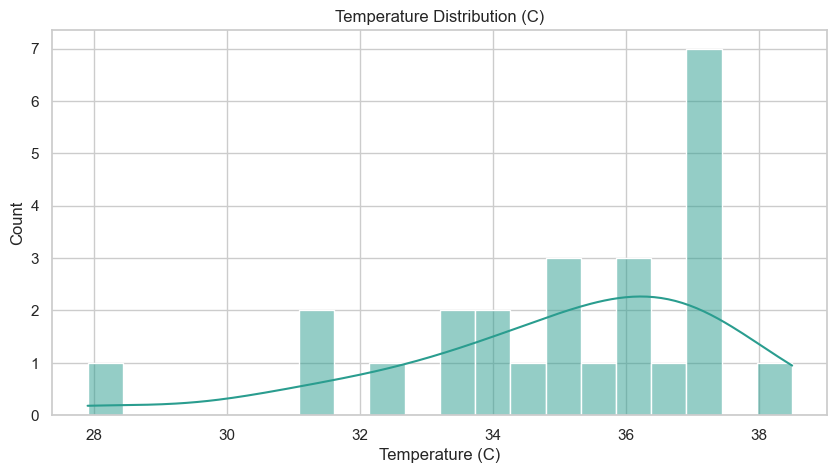

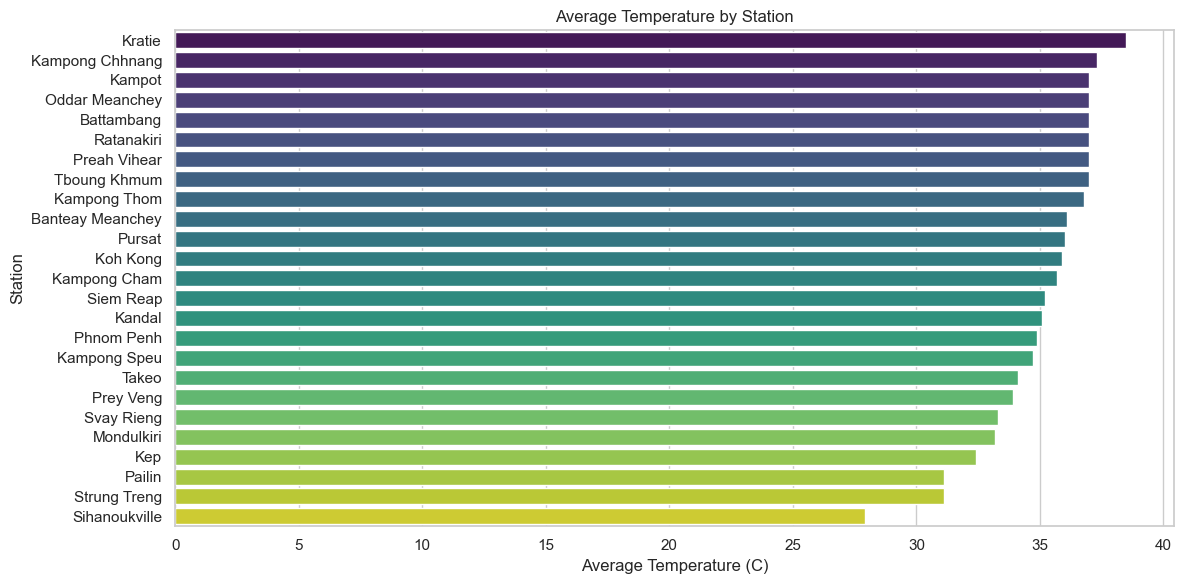

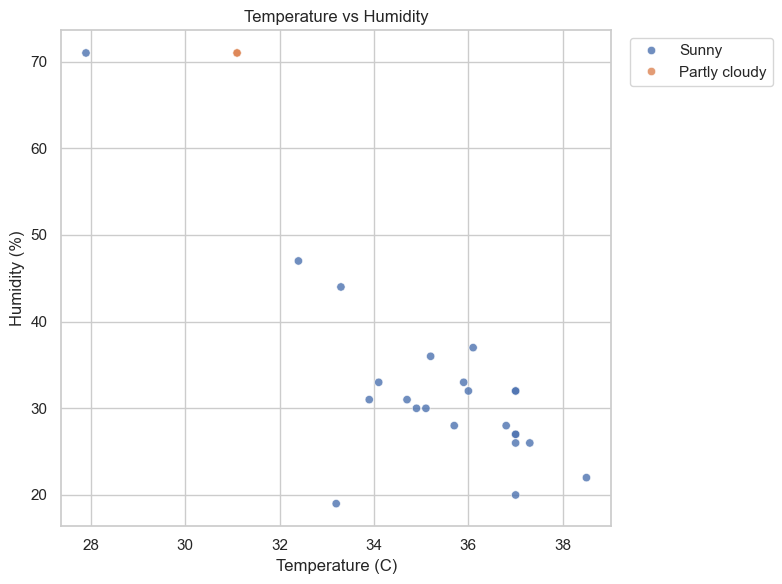

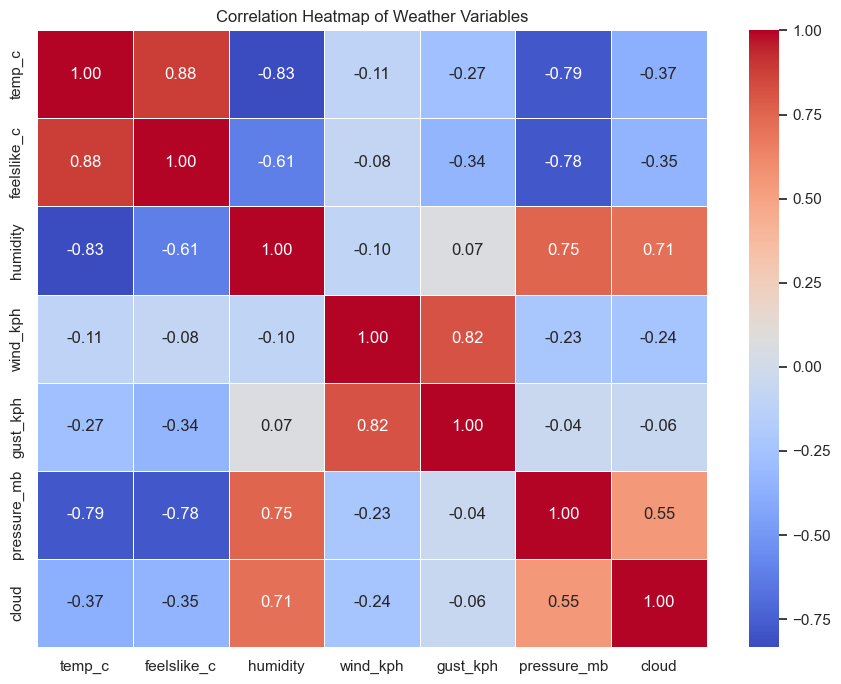

In [ ]:
# EDA visuals and summary statistics
sns.set_theme(style="whitegrid")

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
key_numeric = [c for c in ["temp_c", "humidity", "wind_kph", "pressure_mb", "uv", "cloud"] if c in df_clean.columns]

print(f"Total stations/rows: {len(df_clean)}")
if "name" in df_clean.columns:
    print(f"Unique stations: {df_clean['name'].nunique()}")
    display(df_clean["name"].value_counts().head(10).to_frame("records"))

if key_numeric:
    print("Descriptive statistics (key numeric variables):")
    display(df_clean[key_numeric].describe().T)
else:
    print("No key numeric columns found for descriptive statistics.")

# Distribution of temperature
if "temp_c" in df_clean.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_clean["temp_c"].dropna(), kde=True, bins=20, color="#2a9d8f")
    plt.title("Temperature Distribution (C)")
    plt.xlabel("Temperature (C)")
    plt.ylabel("Count")
    plt.show()

# Station-wise temperature comparison
if set(["name", "temp_c"]).issubset(df_clean.columns):
    station_temp = df_clean.groupby("name", as_index=False)["temp_c"].mean().sort_values("temp_c", ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=station_temp, x="temp_c", y="name", hue="name", palette="viridis", legend=False)
    plt.title("Average Temperature by Station")
    plt.xlabel("Average Temperature (C)")
    plt.ylabel("Station")
    plt.tight_layout()
    plt.show()

# Relationship between temperature and humidity
if set(["temp_c", "humidity"]).issubset(df_clean.columns):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_clean,
        x="temp_c",
        y="humidity",
        hue="condition.text" if "condition.text" in df_clean.columns else None,
        alpha=0.8
    )
    plt.title("Temperature vs Humidity")
    plt.xlabel("Temperature (C)")
    plt.ylabel("Humidity (%)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left") if "condition.text" in df_clean.columns else None
    plt.tight_layout()
    plt.show()

# Correlation heatmap
corr_cols = [c for c in ["temp_c", "feelslike_c", "humidity", "wind_kph", "gust_kph", "pressure_mb", "uv", "cloud"] if c in df_clean.columns]
if len(corr_cols) >= 3:
    corr_input = df_clean[corr_cols].dropna(axis=1, how="all")
    if corr_input.shape[1] >= 3:
        plt.figure(figsize=(9, 7))
        corr = corr_input.corr(numeric_only=True)
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Heatmap of Weather Variables")
        plt.tight_layout()
        plt.show()

In [ ]:
# Save snapshot for reproducible future analysis
snapshot_path = "../data/weather_forecast_snapshot_latest.csv"
df_clean.to_csv(snapshot_path, index=False)
print(f"Snapshot saved to: {snapshot_path}")

# Quick insights table + summary
insights = {}
if "temp_c" in df_clean.columns:
    insights["avg_temp_c"] = round(df_clean["temp_c"].mean(), 2)
    insights["min_temp_c"] = round(df_clean["temp_c"].min(), 2)
    insights["max_temp_c"] = round(df_clean["temp_c"].max(), 2)
if "humidity" in df_clean.columns:
    insights["avg_humidity_pct"] = round(df_clean["humidity"].mean(), 2)
if "wind_kph" in df_clean.columns:
    insights["avg_wind_kph"] = round(df_clean["wind_kph"].mean(), 2)
if "condition.text" in df_clean.columns:
    top_condition = df_clean["condition.text"].value_counts().head(1)
    if not top_condition.empty:
        insights["most_common_condition"] = top_condition.index[0]

insights_df = pd.DataFrame([insights])
display(insights_df)

print("\nPlain-language summary:")
if not insights_df.empty:
    row = insights_df.iloc[0]
    if "avg_temp_c" in row:
        print(f"- Average temperature is around {row['avg_temp_c']} C.")
    if "avg_humidity_pct" in row:
        print(f"- Average humidity is about {row['avg_humidity_pct']}%.")
    if "avg_wind_kph" in row:
        print(f"- Average wind speed is close to {row['avg_wind_kph']} kph.")
    if "most_common_condition" in row:
        print(f"- Most common condition in this snapshot: {row['most_common_condition']}.")

Snapshot saved to: ../data/weather_forecast_snapshot_latest.csv


,avg_temp_c,min_temp_c,max_temp_c,avg_humidity_pct,avg_wind_kph,most_common_condition
0,35.01,27.9,38.5,35.36,8.58,Sunny



Plain-language summary:
- Average temperature is around 35.01 C.
- Average humidity is about 35.36%.
- Average wind speed is close to 8.58 kph.
- Most common condition in this snapshot: Sunny.


# Conclusion
This run gives us a clean and readable snapshot of Cambodia weather conditions across stations.

Main takeaway: temperature is generally high across the country, with station-level differences in humidity and wind that are worth tracking over repeated snapshots.

Next step for the team is to run this notebook regularly, append new snapshots, and turn these one-time insights into real trend analysis.

## Temperature Prediction Model (Next-Day Forecast)

This section builds a baseline regression model to predict temperature 24 hours ahead using historical Open-Meteo hourly data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [ ]:
# Load historical Open-Meteo data
# File format contains metadata rows before the actual table header.
open_meteo_path = "../data/open-meteo-13.00N105.00E36m.csv"
hist_df = pd.read_csv(open_meteo_path, skiprows=3)

# Robustly find temperature and pressure columns (handles encoding issues)
temp_col = [c for c in hist_df.columns if "temperature_2m" in c][0]
pres_col = [c for c in hist_df.columns if "pressure_msl" in c][0]

hist_df = hist_df.rename(columns={temp_col: "temp_c", pres_col: "pressure_hpa"})
hist_df["time"] = pd.to_datetime(hist_df["time"], errors="coerce")

# Keep rows required for modeling and sort by time
hist_df = (
    hist_df.dropna(subset=["time", "temp_c"])
    .sort_values("time")
    .reset_index(drop=True)
)

print("Historical rows after cleaning:", len(hist_df))
print("Time range:", hist_df["time"].min(), "to", hist_df["time"].max())

Historical rows after cleaning: 41904
Time range: 2021-03-23 00:00:00 to 2026-01-01 23:00:00


In [ ]:
# Time features
hist_df["hour"] = hist_df["time"].dt.hour
hist_df["dayofyear"] = hist_df["time"].dt.dayofyear
hist_df["dow"] = hist_df["time"].dt.dayofweek

# Cyclical encoding for periodic features
hist_df["hour_sin"] = np.sin(2 * np.pi * hist_df["hour"] / 24)
hist_df["hour_cos"] = np.cos(2 * np.pi * hist_df["hour"] / 24)
hist_df["doy_sin"] = np.sin(2 * np.pi * hist_df["dayofyear"] / 365.25)
hist_df["doy_cos"] = np.cos(2 * np.pi * hist_df["dayofyear"] / 365.25)

# Lag and rolling features
hist_df["temp_lag_1"] = hist_df["temp_c"].shift(1)
hist_df["temp_lag_24"] = hist_df["temp_c"].shift(24)
hist_df["temp_lag_48"] = hist_df["temp_c"].shift(48)
hist_df["temp_roll_24"] = hist_df["temp_c"].rolling(24).mean()
hist_df["temp_roll_72"] = hist_df["temp_c"].rolling(72).mean()
hist_df["pressure_lag_1"] = hist_df["pressure_hpa"].shift(1)

# Target: next-day (24h ahead) temperature
hist_df["target_temp_next_day"] = hist_df["temp_c"].shift(-24)

feature_cols = [
    "pressure_hpa", "hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow",
    "temp_lag_1", "temp_lag_24", "temp_lag_48", "temp_roll_24", "temp_roll_72", "pressure_lag_1"
]

model_df = hist_df.dropna(subset=feature_cols + ["target_temp_next_day"]).copy()
X = model_df[feature_cols]
y = model_df["target_temp_next_day"]

print("Model-ready rows:", len(model_df))

Model-ready rows: 41809


Train rows: 33447 | Test rows: 8362
MAE (next day): 0.865 C
RMSE (next day): 1.162 C
Model saved to: ../data/temp_next_day_rf_model.joblib


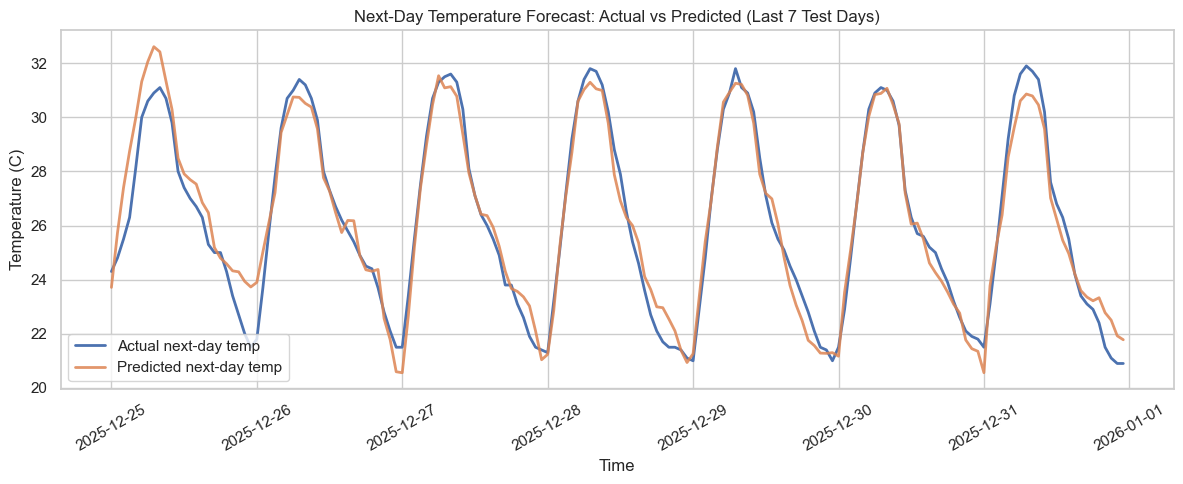

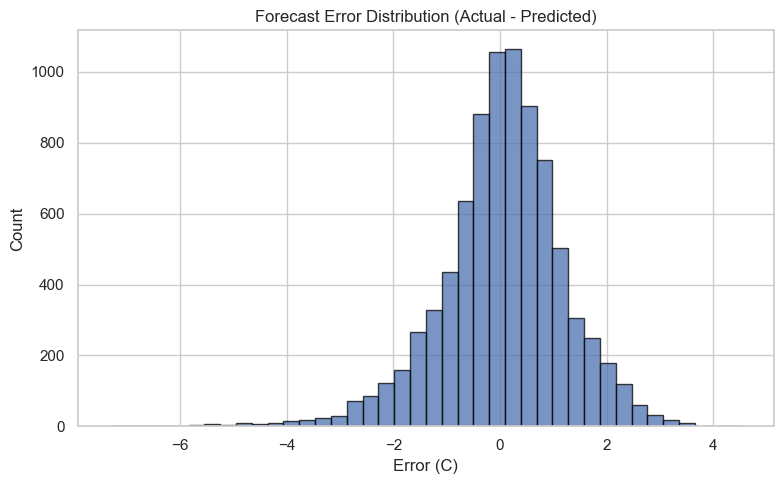

In [ ]:
# Time-based split (no random shuffling)
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Baseline model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Evaluation
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print(f"MAE (next day): {mae:.3f} C")
print(f"RMSE (next day): {rmse:.3f} C")

# Save model for reuse
model_path = "../data/temp_next_day_rf_model.joblib"
joblib.dump(model, model_path)
print("Model saved to:", model_path)

# Plot 1: Actual vs Predicted (latest 7 days of test period)
plot_n = min(24 * 7, len(y_test))
plot_time = model_df.iloc[split_idx:]["time"].iloc[-plot_n:]
plot_actual = y_test.iloc[-plot_n:]
plot_pred = pred[-plot_n:]

plt.figure(figsize=(12, 5))
plt.plot(plot_time, plot_actual, label="Actual next-day temp", linewidth=2)
plt.plot(plot_time, plot_pred, label="Predicted next-day temp", linewidth=2, alpha=0.85)
plt.title("Next-Day Temperature Forecast: Actual vs Predicted (Last 7 Test Days)")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Prediction error distribution
errors = y_test.values - pred
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor="black", alpha=0.75)
plt.title("Forecast Error Distribution (Actual - Predicted)")
plt.xlabel("Error (C)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Quick preview: predicted vs actual for next-day temperature
preview = pd.DataFrame({
    "time": model_df.iloc[split_idx:]["time"].values,
    "actual_temp_next_day": y_test.values,
    "pred_temp_next_day": pred
})
preview.tail(10)

,time,actual_temp_next_day,pred_temp_next_day
8352,2025-12-31 14:00:00,25.5,24.964470
8353,2025-12-31 15:00:00,24.2,24.214462
8354,2025-12-31 16:00:00,23.4,23.592607
8355,2025-12-31 17:00:00,23.1,23.355271
8356,2025-12-31 18:00:00,22.9,23.217346
8357,2025-12-31 19:00:00,22.4,23.329793
8358,2025-12-31 20:00:00,21.5,22.776480
8359,2025-12-31 21:00:00,21.1,22.502106
8360,2025-12-31 22:00:00,20.9,21.921532
8361,2025-12-31 23:00:00,20.9,21.777056


## Location Rain Status (Current Snapshot, Not Next-Day)

This section predicts rain status for the current API snapshot by location and assigns an icon.

Note: this is not a next-day rain forecast model. A reliable next-day rain model needs historical labeled rain data across many days.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Use latest snapshot data for per-location current rain status
snap = pd.read_csv("../data/weather_forecast_snapshot_latest.csv")

# Build target from known weather fields
rain_keywords = "rain|drizzle|shower|thunder|storm|sleet|snow"
text_has_rain = snap.get("condition.text", pd.Series([""] * len(snap))).astype(str).str.contains(rain_keywords, case=False, regex=True)
precip_positive = pd.to_numeric(snap.get("precip_mm", 0), errors="coerce").fillna(0).gt(0)

snap["rain_target"] = (text_has_rain | precip_positive).astype(int)

feature_candidates = ["temp_c", "feelslike_c", "humidity", "cloud", "pressure_mb", "wind_kph", "gust_kph", "dewpoint_c"]
feature_cols_cls = [c for c in feature_candidates if c in snap.columns]

for c in feature_cols_cls:
    snap[c] = pd.to_numeric(snap[c], errors="coerce")

# Fallback icon mapping (WeatherAPI icon codes)
RAIN_ICON = "//cdn.weatherapi.com/weather/64x64/day/296.png"      # light rain
PARTLY_ICON = "//cdn.weatherapi.com/weather/64x64/day/116.png"    # partly cloudy
SUNNY_ICON = "//cdn.weatherapi.com/weather/64x64/day/113.png"     # sunny

if len(feature_cols_cls) >= 3 and snap["rain_target"].nunique() >= 2 and len(snap) >= 20:
    # Train quick classifier and predict on the snapshot rows
    X_cls = snap[feature_cols_cls].copy()
    X_cls = X_cls.fillna(X_cls.median(numeric_only=True))
    y_cls = snap["rain_target"]

    clf = RandomForestClassifier(n_estimators=300, random_state=42)
    clf.fit(X_cls, y_cls)
    snap["pred_rain_now"] = clf.predict(X_cls)
    method_used = "classifier"
else:
    # Current dataset has little/no rain class, so use robust weather rules.
    snap["pred_rain_now"] = (
        precip_positive
        | text_has_rain
        | (pd.to_numeric(snap.get("humidity", 0), errors="coerce").fillna(0) >= 85)
          & (pd.to_numeric(snap.get("cloud", 0), errors="coerce").fillna(0) >= 70)
    ).astype(int)
    method_used = "rule-based fallback"

snap["pred_rain_now_label"] = snap["pred_rain_now"].map({1: "Rain", 0: "No Rain"})

# Predicted icon from predicted rain and cloudiness
cloud_num = pd.to_numeric(snap.get("cloud", 0), errors="coerce").fillna(0)
snap["pred_condition_icon_now"] = np.where(
    snap["pred_rain_now"].eq(1),
    RAIN_ICON,
    np.where(cloud_num >= 45, PARTLY_ICON, SUNNY_ICON)
)

snap["prediction_horizon"] = "current snapshot"

result_cols = [
    c for c in [
        "name", "prediction_horizon", "pred_rain_now_label", "pred_condition_icon_now",
        "condition.text", "condition.icon", "humidity", "cloud", "precip_mm"
    ] if c in snap.columns
]
rain_prediction_by_location = snap[result_cols].sort_values(by="name")

display(rain_prediction_by_location)
print("\nMethod:", method_used)
print("This output is for CURRENT snapshot, not next-day rain forecast.")
print("\nRain status counts:")
print(rain_prediction_by_location["pred_rain_now_label"].value_counts())

,name,prediction_horizon,pred_rain_now_label,pred_condition_icon_now,condition.text,condition.icon,humidity,cloud,precip_mm
4,Banteay Meanchey,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,37,14,0.0
11,Battambang,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,32,10,0.0
23,Kampong Cham,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,28,8,0.0
20,Kampong Chhnang,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,26,10,0.0
22,Kampong Speu,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,31,4,0.0
17,Kampong Thom,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,28,13,0.0
15,Kampot,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,26,8,0.0
19,Kandal,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,30,8,0.0
16,Kep,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,47,6,0.0
13,Koh Kong,current snapshot,No Rain,//cdn.weatherapi.com/weather/64x64/day/113.png,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,33,16,0.0



Method: rule-based fallback
This output is for CURRENT snapshot, not next-day rain forecast.

Rain status counts:
pred_rain_now_label
No Rain    25
Name: count, dtype: int64
